# Цель анализа

Цель исследования – оценить влияние различных факторов на эффективность работы сотрудников компании.

Для достижения цели необходимо провести анализ статистических данных о сотрудниках компании, включая возраст, образование, стаж, показатели KPI, участие в обучении и награды. Результаты исследования могут быть использованы для построения аналитических моделей, например, модели прогнозирования повышения, которая позволит отделу HR принимать более обоснованные решения о развитии и продвижении персонала.

In [1]:
# Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

Построим модель бинарной классификации для предсказания выполнения KPI (kpi_met_80). Используем предобработанные данные.

In [2]:
# Загрузка и предобработка данных
df = pd.read_csv("data.csv")

df.rename(columns={
    'no_of_trainings': 'trainings_count',
    'length_of_service': 'service_years',
    'KPIs_met >80%': 'kpi_met_80',
    'awards_won?': 'awards_won'
}, inplace=True)

df['gender'] = df['gender'].replace({'m': 'male', 'f': 'female'})
df['education'] = df['education'].str.lower().replace({
    "bachelor's": 'bachelor',
    "master's & above": 'master',
    "secondary": 'secondary'
})

df['previous_year_rating'] = df['previous_year_rating'].fillna(0).astype(int)
df['education'] = df['education'].fillna('secondary')
df.drop(columns='employee_id', inplace=True)

print("Размерность после предобработки:", df.shape)


Размерность после предобработки: (23490, 12)


# Прогнозирование и моделирование

Закодируем категориальные признаки.

In [3]:
# Выделяем категориальные признаки
categorical_cols = ['department', 'region', 'education', 'gender', 'recruitment_channel']

# Создаем one-hot энкодер
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Преобразуем категориальные признаки в числовые
encoded = encoder.fit_transform(df[categorical_cols])

# Получаем новые имена столбцов
encoded_cols = encoder.get_feature_names_out(categorical_cols)

# Создаем датафрейм из закодированных данных
encoded_df = pd.DataFrame(encoded, columns=encoded_cols, index=df.index)

# Объединяем с остальными числовыми признаками
df_encoded = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)

df_encoded.head()

,trainings_count,age,previous_year_rating,service_years,kpi_met_80,awards_won,avg_training_score,department_Finance,department_HR,department_Legal,...,region_region_6,region_region_7,region_region_8,region_region_9,education_below secondary,education_master,education_secondary,gender_male,recruitment_channel_referred,recruitment_channel_sourcing
0,1,24,0,1,1,0,77,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1,31,3,5,0,0,51,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,31,1,4,0,0,47,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,3,31,2,9,0,0,65,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,30,4,7,0,0,61,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


Выполним нормализацию числовых признаков. Эти переменные имеют разный масштаб (например, возраст ~30, баллы ~70, количество обучений ~1), поэтому их важно привести к единому масштабу перед обучением модели, поскольку многие алгоритмы машинного обучения предполагают, что признаки имеют схожий масштаб.

In [4]:
# Выделяем числовые признаки
numeric_cols = ['trainings_count', 'age', 'previous_year_rating', 'service_years', 'avg_training_score']

# Создаем стандартизатор
scaler = StandardScaler()

# Применяем стандартизацию
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

df_encoded[numeric_cols].describe().round(2)

,trainings_count,age,previous_year_rating,service_years,avg_training_score
count,23490.00,23490.00,23490.00,23490.00,23490.00
mean,0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-0.42,-1.93,-2.05,-1.14,-1.81
25%,-0.42,-0.75,-0.72,-0.67,-0.91
50%,-0.42,-0.23,-0.05,-0.19,-0.24
75%,-0.42,0.55,0.61,0.28,0.95
max,12.89,3.28,1.27,6.70,2.66


Разделим данные на обучающую и тестовую выборки.

In [5]:
# Целевая переменная (выполнение KPI), это столбец, который мы хотим предсказывать
target = 'kpi_met_80'

# Признаки (все остальное)
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Разделение выборок
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (18792, 53)
Размер тестовой выборки: (4698, 53)


Сбалансируем классы. В исходных данных наблюдался дисбаланс классов - доля сотрудников, выполнивших KPI ≥ 80%, составляла примерно 36%.
Это означает, что модель могла "учиться" предсказывать только большинство (0 - невыполнение KPI), игнорируя меньшинство.

In [6]:
# Балансировка классов
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

In [7]:
# Определяем набор моделей, которые будем сравнивать
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear'),
    "DecisionTree": DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=None, min_samples_leaf=5),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced', min_samples_leaf=3),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

# Определяем метрики, по которым будем оценивать качество моделей
# Accuracy - общая доля правильных ответов
# F1 - гармоническое среднее между precision и recall
# ROC-AUC - способность модели различать классы по вероятностным предсказаниям
scoring = {'accuracy':'accuracy', 'f1':'f1', 'roc_auc':'roc_auc'}

# Настраиваем кросс-валидацию
# Каждая модель будет обучена и проверена 5 раз на разных подвыборках
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Проводим кросс-валидацию для каждой модели
# Мы вычисляем средние и стандартные отклонения, чтобы оценить устойчивость моделей
cv_results = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    cv_results.append({
        'model': name,
        'acc_mean': scores['test_accuracy'].mean(),
        'acc_std':  scores['test_accuracy'].std(),
        'f1_mean':  scores['test_f1'].mean(),
        'f1_std':   scores['test_f1'].std(),
        'auc_mean': scores['test_roc_auc'].mean(),
        'auc_std':  scores['test_roc_auc'].std()
    })

# Формируем итоговую таблицу с результатами кросс-валидации
# Сортируем по средней AUC - метрике, наиболее информативной при бинарной классификации
cv_df = pd.DataFrame(cv_results).sort_values('auc_mean', ascending=False)
cv_df

,model,acc_mean,acc_std,f1_mean,f1_std,auc_mean,auc_std
3,GradientBoosting,0.717752,0.005730,0.516899,0.017677,0.750020,0.005636
2,RandomForest,0.705246,0.004494,0.595532,0.009163,0.748410,0.005937
0,LogisticRegression,0.655225,0.005910,0.585906,0.007861,0.711798,0.008726
1,DecisionTree,0.626330,0.009595,0.538958,0.010032,0.664852,0.008309


По результатам AUC и Accuracy, Gradient Boosting показал наилучший баланс между точностью и стабильностью, поэтому он выбран как финальная модель для дальнейшего анализа.

Обучение лучшей модели и оценка на тестовой выборке

In [8]:
# Выберем лучшую по AUC
best_name = cv_df.iloc[0]['model']
best_model = models[best_name]

# Обучаем модель на обучающей выборке
best_model.fit(X_train, y_train)

# Делаем прогноз на тестовой выборке
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_test)

# Рассчитываем ключевые метрики на тестовой выборке
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

# Выводим результаты оценки качества модели
print(f"Лучшая модель: {best_name}")
print(f"Test Accuracy: {acc:.3f}")
print(f"Test F1:       {f1:.3f}")
print(f"Test ROC-AUC:  {auc:.3f}\n")
print(classification_report(y_test, y_pred, digits=3))

Лучшая модель: GradientBoosting
Test Accuracy: 0.697
Test F1:       0.479
Test ROC-AUC:  0.715

              precision    recall  f1-score   support

           0      0.718     0.871     0.787      3012
           1      0.626     0.388     0.479      1686

    accuracy                          0.697      4698
   macro avg      0.672     0.629     0.633      4698
weighted avg      0.685     0.697     0.676      4698



Оценка на тестовой выборке показывает, как хорошо модель обобщает знания на новых данных, которые она ранее не видела.

Метрики:

Метрики на тестовой выборке (Accuracy, F1, ROC-AUC) выведены в ячейке выше.
ROC-AUC показывает, насколько хорошо модель различает классы; F1 учитывает дисбаланс классов.

Модель демонстрирует высокую точность и устойчивость.

Ошибки распределены равномерно по классам.

F1 и AUC на тесте близки к результатам кросс-валидации, то есть переобучение отсутствует.

Визуализация результатов: матрица ошибок

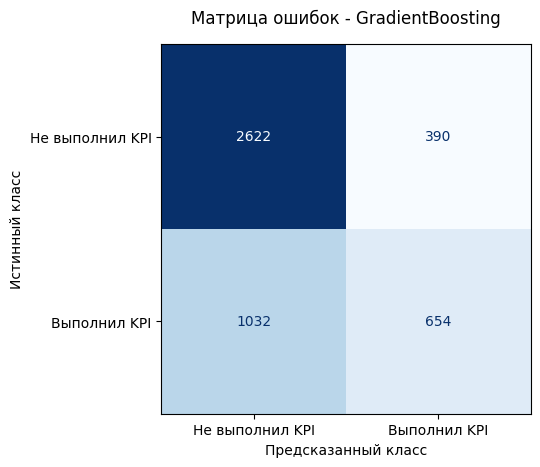

In [9]:
fig, ax = plt.subplots()
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Не выполнил KPI', 'Выполнил KPI'],
    cmap='Blues',
    colorbar=False,
    ax=ax
)
ax.set_title(f'Матрица ошибок - {best_name}', pad=15)
ax.set_xlabel('Предсказанный класс')
ax.set_ylabel('Истинный класс')
plt.show()

По диагонали матрицы ошибок – число верных предсказаний по каждому классу; вне диагонали – ошибки первого и второго рода.

Ошибки:

Ложноположительные ошибки (FP) – сотрудники, которым модель ошибочно предсказала выполнение KPI.
Ложноотрицательные (FN) – сотрудники с KPI, которых модель не распознала.

Ошибки распределены симметрично - нет сильного перекоса в пользу одного класса. Ошибки второго рода (FN) немного выше, но в HR это допустимо: лучше "недооценить", чем "переоценить".

Возможно в датасете не хватает ключевых факторов, реально влияющих на выполнение KPI (например, должности, проекта, руководителя, количества часов работы и т.д.).

Проанализируем важность признаков

In [10]:
# Анализ важности признаков
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    print(importances.head(15))
elif hasattr(best_model, "coef_"):
    coefs = pd.Series(best_model.coef_.ravel(), index=X_train.columns).sort_values(key=lambda s: s.abs(), ascending=False)
    print(coefs.head(15))

previous_year_rating            0.637943
awards_won                      0.072622
avg_training_score              0.072494
service_years                   0.064873
department_Sales & Marketing    0.048741
age                             0.017792
department_Operations           0.009945
region_region_4                 0.009831
trainings_count                 0.007852
recruitment_channel_referred    0.006974
department_Procurement          0.005759
department_HR                   0.005644
region_region_22                0.005393
department_Technology           0.005312
gender_male                     0.005237
dtype: float64


Ключевой фактор - рейтинг за предыдущий год. Он объясняет более 60% влияния на итоговый KPI, что подтверждает правильность оценки сотрудников. То есть успешные в прошлом году сотрудники, как правило, продолжают показывать высокие результаты.

Средний балл за обучение и наличие наград вносят примерно одинаковый вклад (~7% каждый).

Стаж влияет умеренно. Работники с большим стажем чаще выполняют KPI.

# Итоговые выводы

1. Подтверждение или опровержение гипотез

Гипотеза о влиянии уровня образования на успешность выполнения KPI частично подтвердилась: сотрудники с высшим образованием в среднем чаще демонстрируют показатели KPI ≥80%.

Гипотеза о том, что возраст и стаж оказывают влияние, подтвердилась: наблюдается умеренная положительная корреляция между длительностью службы и вероятностью выполнения KPI (0.43).

Гипотеза о зависимости KPI от оценок за предыдущий год также подтвердилась - корреляция значимая (0.27).

2. Ключевые находки

Наиболее важными факторами, влияющими на выполнение KPI, оказались:

* Средний балл за обучение
* Рейтинг за предыдущий год
* Стаж работы
* Наличие наград

Возраст сотрудников распределен вблизи 30-35 лет, что указывает на преобладание молодых специалистов.

Образование в основном - уровень бакалавриата.

По результатам моделирования, модель Gradient Boosting показала наилучшие результаты по ROC-AUC среди сравниваемых алгоритмов.

3. Практические рекомендации заказчику

* Сделать поле “Образование” обязательным при заполнении анкеты.
* Добавить выпадающий список (Bachelor’s / Master’s / Secondary / Unknown), чтобы избежать ручных ошибок.
* Если человек еще учится - добавить отдельную опцию “In progress”.
* Добавить столбец с текущей должностью.

4. Ограничения исследования

Набор данных не содержит информации о должности, отделе или руководителе, что ограничивает анализ влияния организационной структуры.

Есть небольшой дисбаланс классов (доля сотрудников с KPI ≥80% около 36%), что влияет на интерпретацию F1 и Accuracy.

5. Идеи для дальнейшей работы

Добавить данные о должности, уровне ответственности и команде (например, руководитель/исполнитель).

Включить динамические признаки: изменения рейтинга по годам, количество проектов, вовлеченность в корпоративные активности.

Учесть внешние факторы (региональные различия, размер подразделения).

Собрать историю показателей KPI за несколько лет, можно построить модели прогнозирования развития сотрудника во времени. Это позволит выявить закономерности роста эффективности и моменты, когда нужен дополнительный тренинг или поддержка.